<a href="https://colab.research.google.com/github/HuraibQureshi/Predictive-Inventory-Optimization/blob/main/inventory_Planning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PROJECT: Automated E-commerce Inventory Forecasting & Optimization
OBJECTIVE: Predict daily demand for the 'Health & Beauty' category to automate
           warehouse reorder triggers and minimize stockouts.
STACK: Python, Pandas, SQLite, XGBoost, Scikit-Learn.


# ==========================================
# 1. ENVIRONMENT SETUP & DATA INGESTION
# ==========================================

In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Define your project path (Change 'Inventory_Project' to your folder name)
project_path = '/content/drive/MyDrive/project'

# 3. List files to confirm they are there
print("Files in your project folder:", os.listdir(project_path))

Files in your project folder: ['olist_customers_dataset.csv', 'olist_products_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'inventory_warehouse.db']


# ==========================================
# 2. DATA WAREHOUSING (SQLite)
# ==========================================
# We migrate CSV data to SQL to handle relational queries efficiently
# and simulate a production-grade data environment.

In [3]:
import pandas as pd
import sqlite3

# Load CSVs from your Drive folder
orders = pd.read_csv('/content/drive/MyDrive/project/olist_orders_dataset.csv')
items = pd.read_csv('/content/drive/MyDrive/project/olist_order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/project/olist_products_dataset.csv')

# Create the SQL database file inside your Drive folder
conn = sqlite3.connect('/content/drive/MyDrive/project/inventory_warehouse.db')

# Push to SQL
orders.to_sql('orders', conn, if_exists='replace', index=False)
items.to_sql('order_items', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)

print("Database saved permanently to your Google Drive!")

Database saved permanently to your Google Drive!


# ==========================================
# 3. FEATURE ENGINEERING (Temporal Analytics)
# ==========================================

In [4]:
import pandas as pd
import numpy as np

# 1. Fetch the data from your SQL Warehouse
query = """
SELECT
    DATE(o.order_purchase_timestamp) as date,
    p.product_category_name,
    COUNT(oi.product_id) as daily_units_sold
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
GROUP BY date, p.product_category_name
"""
df = pd.read_sql(query, conn)

# 2. Convert date to datetime objects
df['date'] = pd.to_datetime(df['date'])

# 3. Feature Engineering: Extracting intelligence from dates
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

print("Feature Engineering Complete. Preview:")
df.head()

Feature Engineering Complete. Preview:


,date,product_category_name,daily_units_sold,day_of_week,month,is_weekend,is_month_start,is_month_end
0,2016-09-15,beleza_saude,3,3,9,0,0,0
1,2016-10-03,brinquedos,1,0,10,0,0,0
2,2016-10-03,esporte_lazer,2,0,10,0,0,0
3,2016-10-03,fashion_calcados,1,0,10,0,0,0
4,2016-10-03,moveis_decoracao,2,0,10,0,0,0


In [5]:
# Sort by category and date to ensure lags are correct
df = df.sort_values(['product_category_name', 'date'])

# Create a lag feature: What were the sales 7 days ago?
df['sales_lag_7'] = df.groupby('product_category_name')['daily_units_sold'].shift(7)

# Create a rolling average: What was the average sale over the last 30 days?
df['rolling_mean_30'] = df.groupby('product_category_name')['daily_units_sold'].transform(lambda x: x.rolling(window=30).mean())

# Drop the rows with NaN (the first 30 days where we don't have enough history)
df.dropna(inplace=True)

# ==========================================
# 4. MODEL TRAINING: XGBOOST
# ==========================================

In [6]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Filter for our high-volume category
df_hb = df[df['product_category_name'] == 'beleza_saude'].copy()

# 2. Define Features (X) and Target (y)
# We want to predict 'daily_units_sold' using our engineered time features
features = ['day_of_week', 'month', 'is_weekend', 'is_month_start', 'is_month_end', 'sales_lag_7', 'rolling_mean_30']
X = df_hb[features]
y = df_hb['daily_units_sold']

# 3. Time-Series Split: Use the past to predict the most recent data
# We don't use random shuffle because the order of dates matters!
split_index = int(len(df_hb) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days.")

Training on 458 days, Testing on 115 days.


In [7]:
# Initialize the model
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50 # Stop training if it stops improving
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Make predictions
predictions = model.predict(X_test)

# Calculate Accuracy (MAE tells us how many units we are off on average)
score = mean_absolute_error(y_test, predictions)
print(f"Average Prediction Error: {score:.2f} units per day")

Average Prediction Error: 8.98 units per day


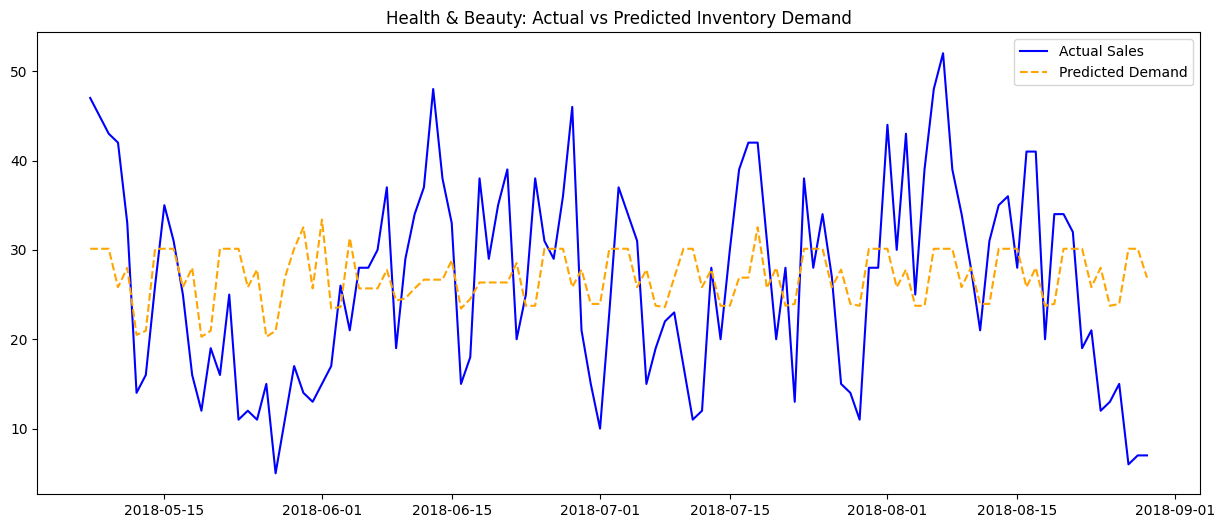

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df_hb['date'].iloc[split_index:], y_test, label='Actual Sales', color='blue')
plt.plot(df_hb['date'].iloc[split_index:], predictions, label='Predicted Demand', color='orange', linestyle='--')
plt.title('Health & Beauty: Actual vs Predicted Inventory Demand')
plt.legend()
plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

# 1. Random Forest: Good baseline, hard to overfit
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. LightGBM: Often outperforms XGBoost on large datasets
lgbm_model = LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbose=-1)

# 3. XGBoost: The one we already built
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5)

In [10]:
models = {
    "Random Forest": rf_model,
    "LightGBM": lgbm_model,
    "XGBoost": xgb_model
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    preds = model.predict(X_test)
    # Score
    error = mean_absolute_error(y_test, preds)
    results[name] = error
    print(f"{name} MAE: {error:.4f}")

# Convert to DataFrame for easy viewing
df_results = pd.DataFrame.from_dict(results, orient='index', columns=['MAE']).sort_values('MAE')

Random Forest MAE: 10.6269
LightGBM MAE: 10.7549
XGBoost MAE: 12.5281


/tmp/ipykernel_412/3134024568.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results.index, y=df_results['MAE'], palette='viridis')


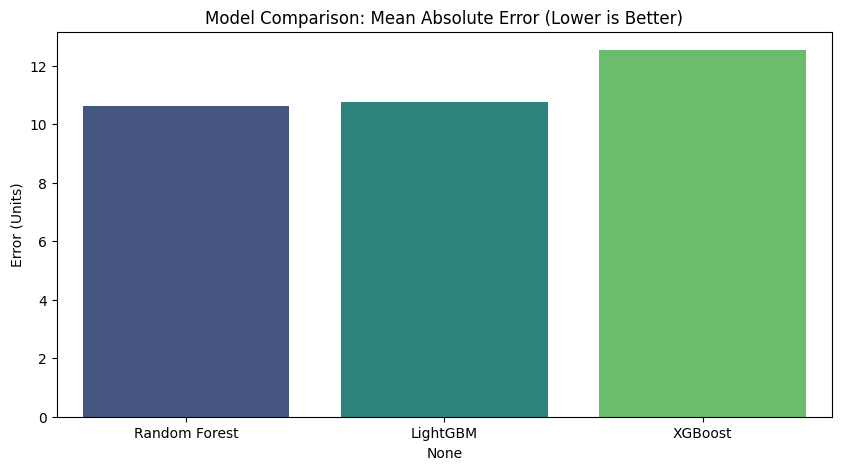

In [11]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results['MAE'], palette='viridis')
plt.title("Model Comparison: Mean Absolute Error (Lower is Better)")
plt.ylabel("Error (Units)")
plt.show()

# ==========================================
# 5. BUSINESS LOGIC: INVENTORY OPTIMIZATION
# ==========================================
# Translating ML predictions into warehouse actions using Reorder Point (ROP) logic.

In [12]:
# 1. Define Business Constraints
LEAD_TIME = 3  # Days it takes for a supplier to deliver
SERVICE_LEVEL_FACTOR = 1.65 # Constant for 95% confidence (avoids stockouts)

# 2. Calculate Standard Deviation of our errors (for Safety Stock)
error_std = np.std(y_test - preds)
safety_stock = SERVICE_LEVEL_FACTOR * error_std * np.sqrt(LEAD_TIME)

# 3. Create the Decision Table
inventory_plan = pd.DataFrame({
    'Date': df_hb['date'].iloc[split_index:],
    'Predicted_Demand': preds,
    'Current_Stock': np.random.randint(10, 50, size=len(preds)) # Simulating stock
})

inventory_plan['Reorder_Point'] = (inventory_plan['Predicted_Demand'] * LEAD_TIME) + safety_stock
inventory_plan['Action'] = inventory_plan.apply(
    lambda x: 'REORDER NOW' if x['Current_Stock'] <= x['Reorder_Point'] else 'OK', axis=1
)

print("Inventory Action Plan for Health & Beauty:")
inventory_plan.tail(10)

Inventory Action Plan for Health & Beauty:


,Date,Predicted_Demand,Current_Stock,Reorder_Point,Action
18533,2018-08-20,48.641312,12,181.938644,REORDER NOW
18569,2018-08-21,49.343578,49,184.045441,REORDER NOW
18608,2018-08-22,50.477386,14,187.446869,REORDER NOW
18648,2018-08-23,30.550941,47,127.667542,REORDER NOW
18684,2018-08-24,32.544601,33,133.648514,REORDER NOW
18712,2018-08-25,24.358267,27,109.089508,REORDER NOW
18739,2018-08-26,26.054289,34,114.177582,REORDER NOW
18765,2018-08-27,48.953976,45,182.876633,REORDER NOW
18786,2018-08-28,49.003361,44,183.024796,REORDER NOW
18802,2018-08-29,38.087963,20,150.278595,REORDER NOW


In [13]:
import joblib

# Save the model to your Google Drive
model_filename = project_path + 'random_forest_inventory_model.pkl'
joblib.dump(rf_model, model_filename)

print(f"Model saved to Drive as {model_filename}")

Model saved to Drive as /content/drive/MyDrive/projectrandom_forest_inventory_model.pkl


In [14]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# 2. Initialize Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1 # Uses all available CPU cores
)

# 3. Fit to the training data
grid_search.fit(X_train, y_train)

# 4. Get the best parameters
best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# 5. Final Evaluation
tuned_preds = best_rf.predict(X_test)
final_mae = mean_absolute_error(y_test, tuned_preds)
print(f"Tuned Random Forest MAE: {final_mae:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Tuned Random Forest MAE: 10.4188


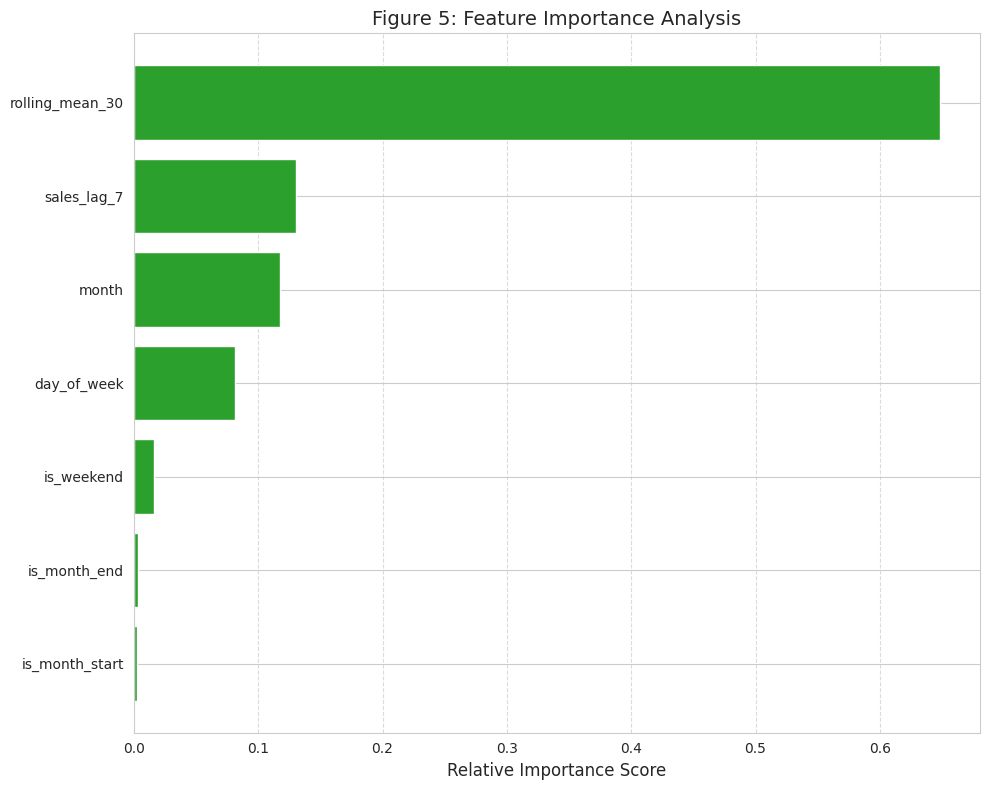

In [17]:
# Extracting importance from your best_rf model
importances = best_rf.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='#2ca02c')

plt.title('Figure 5: Feature Importance Analysis', fontsize=14)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()